In [ ]:
import sqlite3
from pathlib import Path
import sys
import pandas as pd

sys.path.append('..')

DB_PATH = Path('..') / 'database' / 'codepulse.db'
conn = sqlite3.connect(DB_PATH)

events = pd.read_sql('SELECT * FROM events', conn)
pull_requests = pd.read_sql('SELECT * FROM pull_requests', conn)
pr_commits = pd.read_sql('SELECT * FROM pr_commits', conn)
issues = pd.read_sql('SELECT * FROM issues', conn)
commit_issues = pd.read_sql('SELECT * FROM commit_issues', conn)
try:
    commit_labels = pd.read_sql('SELECT * FROM commit_labels', conn)
    file_labels = pd.read_sql('SELECT * FROM file_labels', conn)
except Exception:
    commit_labels = None

conn.close()

In [15]:
events.head()

,commit_hash,committed_at,author_name,author_email,branch,commit_message,file_path,old_path,change_type,lines_added,lines_deleted,num_files_in_commit,is_revert,is_merge,repo
0,b966efa17d837dc62c23d5f8064e184e22b14c2e,2012-02-25 13:39:38+01:00,Jakub Roztočil,jakub@roztocil.name,master,Initial commit.,.gitignore,NaN,ADD,4,0,7,0,0,httpie/cli
1,b966efa17d837dc62c23d5f8064e184e22b14c2e,2012-02-25 13:39:38+01:00,Jakub Roztočil,jakub@roztocil.name,master,Initial commit.,README.md,NaN,ADD,15,0,7,0,0,httpie/cli
2,b966efa17d837dc62c23d5f8064e184e22b14c2e,2012-02-25 13:39:38+01:00,Jakub Roztočil,jakub@roztocil.name,master,Initial commit.,httpie.png,httpie.png,ADD,0,0,7,0,0,httpie/cli
3,b966efa17d837dc62c23d5f8064e184e22b14c2e,2012-02-25 13:39:38+01:00,Jakub Roztočil,jakub@roztocil.name,master,Initial commit.,httpie\__init__.py,httpie\__init__.py,ADD,0,0,7,0,0,httpie/cli
4,b966efa17d837dc62c23d5f8064e184e22b14c2e,2012-02-25 13:39:38+01:00,Jakub Roztočil,jakub@roztocil.name,master,Initial commit.,httpie\httpie.py,NaN,ADD,157,0,7,0,0,httpie/cli


In [ ]:
pull_requests

In [ ]:
pr_commits

In [ ]:
issues

In [8]:
commit_issues.head()

,issue_number,commit_hash,repo
0,1,71b6b126c05b9a7cdec750c9d923d4f03855b577,httpie/cli
1,7,3442a5d037f0bddb1cf4bad55a56dac41b330515,httpie/cli
2,6,94c605fac15b35aa61854546716f7b7f16f82fb6,httpie/cli
3,14,b802f2b960ae5b460ab98d950aefea09baff7957,httpie/cli
4,20,ce952c9e902504267317a4a2fc27088d29e416a1,httpie/cli


In [7]:
commit_labels.head()

,commit_hash,bug_confidence,signals_matched,num_signals,is_bug
0,b966efa17d837dc62c23d5f8064e184e22b14c2e,0.0,NaN,0,0
1,e7dc59e0dbcee5ebb584cfa053a89404b2b9778f,0.0,NaN,0,0
2,4c522bf93290bdae433668b807448e3840251804,0.0,NaN,0,0
3,0373a49d749beac20ad49d05b05391ba1460b4de,0.0,NaN,0,0
4,0577d0731634de3ef23d43e9573792e3845e93e8,0.3,keyword,1,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(commit_labels['bug_confidence'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Bug confidence â€” all commits')
axes[0].set_xlabel('bug_confidence')

nonzero = commit_labels[commit_labels['bug_confidence'] > 0]['bug_confidence']
sns.histplot(nonzero, bins=30, kde=True, color='orange', ax=axes[1])
axes[1].set_title(f'Bug confidence â€” non-zero only ({len(nonzero)} commits)')
axes[1].set_xlabel('bug_confidence')

plt.tight_layout()
plt.show()

## Sanity checks
How much of the data actually carries signal â€” and how noisy is our weakest signal (keyword-only)?

In [32]:
# 1. What fraction of PRs have ANY label at all?
labeled = pull_requests['labels'].fillna('').str.len() > 0
print(f'PRs with at least one label: {labeled.sum()}/{len(pull_requests)} ({labeled.mean():.1%})')

from src.labeling.labeler import has_bug_label
bug_labeled = pull_requests['labels'].apply(has_bug_label)
print(f'PRs with a bug-pattern label:  {bug_labeled.sum()}/{len(pull_requests)} ({bug_labeled.mean():.1%})')

PRs with at least one label: 76/726 (10.5%)
PRs with a bug-pattern label:  10/726 (1.4%)


In [33]:
# 2. Sample 15 keyword-only commits â€” are these real bugs or false positives?
keyword_only = commit_labels[commit_labels['signals_matched'] == 'keyword']
sample = keyword_only.merge(
    events[['commit_hash', 'commit_message']].drop_duplicates(),
    on='commit_hash'
)[['commit_hash', 'commit_message']].sample(15, random_state=42)

for _, row in sample.iterrows():
    short_hash = row['commit_hash'][:8]
    first_line = row['commit_message'].split('\n')[0][:90]
    print(f'  {short_hash}  {first_line}')

  851412c6  Improved error messages.
  ecf96838  Fixed __version__ and __doc__ import. Thanks, @FND.
  e8b22d8b  exclude site-packages from .rst file scanning (#820)
  74e4d0b6  Added JSON detection when ``--json, -j`` is set
  238b2e04  Fixing tests for Travis.
  d920f208  Issue #54 Method suggestion proposal
  ff6f1887  [Major] UI Enhancements (#1321)
  b88e88d2  Fix tests for installation with pyOpenSSL #729
  86f4bf4d  Add support for sending secure cookies over localhost (#1327)
  0fc6331e  Change `PyPi` to `PyPI` (#1203)
  ecbbad81  Fix coveralls integration
  1c5fd184  Python 3 fixes (travis config).
  6238b59e  Fix formatting
  a7321d8a  ðŸ”¥ Remove $ from code fenced examples on readme (#1435)
  a94d6d80  Packit: Enable the Koji repsitory in Copr (#1119)


In [34]:
# 3. What are the most common labels in this repo? Spot bug labels we might be missing.
all_labels = (pull_requests['labels'].fillna('')
              .str.split(',').explode().str.strip())
all_labels = all_labels[all_labels != '']
all_labels.value_counts().head(20)

labels
enhancement             33
stale                   19
dependencies            13
bug                     10
windows                  3
needs product design     1
extensions               1
planned                  1
duplicate                1
docs                     1
wontfix                  1
Name: count, dtype: int64

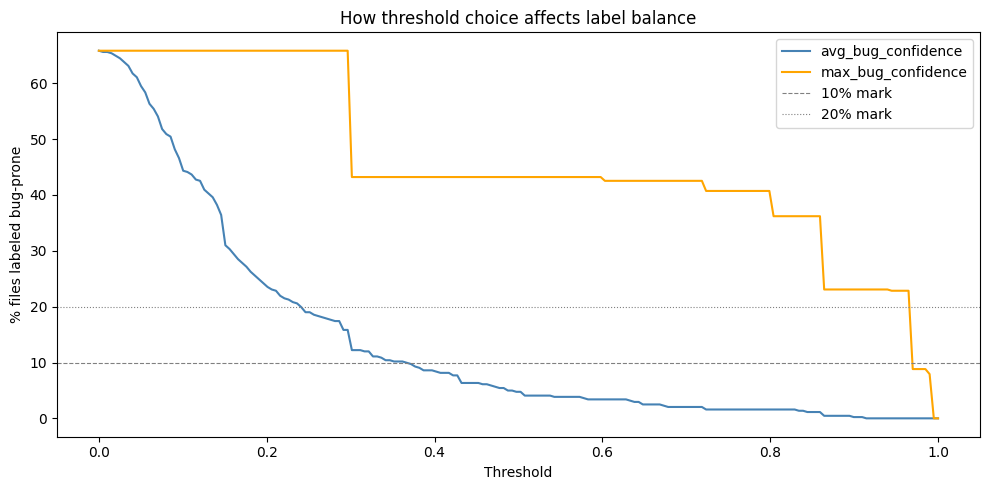

In [5]:
import numpy as np
import matplotlib.pyplot as plt
file_labels = pd.read_sql("SELECT * FROM file_labels", sqlite3.connect(DB_PATH))

thresholds = np.linspace(0, 1, 200)

avg_pct = [(file_labels["avg_bug_confidence"] > t).mean() * 100 for t in thresholds]
max_pct = [(file_labels["max_bug_confidence"] > t).mean() * 100 for t in thresholds]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, avg_pct, label="avg_bug_confidence", color="steelblue")
ax.plot(thresholds, max_pct, label="max_bug_confidence", color="orange")
ax.axhline(10, color="gray", linestyle="--", linewidth=0.8, label="10% mark")
ax.axhline(20, color="gray", linestyle=":",  linewidth=0.8, label="20% mark")
ax.set_xlabel("Threshold")
ax.set_ylabel("% files labeled bug-prone")
ax.set_title("How threshold choice affects label balance")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
avg_pct = (file_labels["avg_bug_confidence"] > 0.23).mean() * 100
print(avg_pct)

20.81447963800905


for avg bug score 0.25 we are having 24.022% files bug prone 

In [16]:
file_labels.shape

(442, 15)

In [17]:
file_labels.head()

,file_path,num_commits,num_authors,total_lines_added,total_lines_deleted,first_seen,last_seen,num_bug_commits,max_bug_confidence,avg_bug_confidence,is_bug_prone,repo,cutoff_date,total_lines_changed,age_days
0,docs\contributors\fetch.py,2,2,281,0,2021-10-14 08:33:14+00:00,2022-05-05 18:19:19+00:00,1,0.860,0.43000,0,httpie/cli,2024-08-03 17:29:56+00:00,281,203
1,docs\contributors\generate.py,4,2,56,3,2021-10-14 08:33:14+00:00,2022-05-05 18:19:19+00:00,1,0.860,0.21500,0,httpie/cli,2024-08-03 17:29:56+00:00,59,203
2,docs\installation\generate.py,2,2,86,1,2021-10-06 09:18:27+00:00,2022-10-01 10:34:41+00:00,2,0.965,0.91250,0,httpie/cli,2024-08-03 17:29:56+00:00,87,360
3,docs\linter\mdl-styles.rb,1,1,39,0,2021-09-09 13:52:24+00:00,2021-09-09 13:52:24+00:00,1,0.300,0.30000,0,httpie/cli,2024-08-03 17:29:56+00:00,39,0
4,docs\markdownlint.rb,4,3,11,0,2021-10-06 09:18:27+00:00,2022-04-14 15:11:12+00:00,2,0.965,0.45625,0,httpie/cli,2024-08-03 17:29:56+00:00,11,190
